<a href="https://colab.research.google.com/github/dukyoon13/Python/blob/main/Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount("/content/drive")

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프 그리는 모듈    # 모듈 = 파일
import matplotlib.font_manager as fm # 폰트 관리하는 모듈

# 드라이브 내 폰트 경로
font_path = '/content/drive/MyDrive/kwu/bigData/dataPreProcessing/NanumGothic.ttf'

font = fm.fontManager.addfont(font_path)
mpl.rc('font', family = 'NanumGothic') # matplotlib 기본 폰트로 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print("현재 폰트: ", plt.rcParams['font.family']) # 현재 적용된 폰트 이름 출력



Mounted at /content/drive
현재 폰트:  ['NanumGothic']


In [3]:
import pandas as pd # 데이터프레임 조작
import numpy as np # 수치 계산 및 NaN 처리
import matplotlib.pyplot as plt # 그래프 시각화
import seaborn as sns # 통계 시각화

# 타이타닉 데이터 로드
titanic = pd.read_csv('/content/drive/MyDrive/kwu/bigData/dataPreProcessing/train.csv')
print(titanic.shape)
titanic.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 결측치의 특성 확인
import numpy as np # np.nan 결측치 사용

print(np.nan == np.nan) # NaN은 자기 자신과도 같지 않음, 결측치 비교 불가
print(np.nan == 0)      # NaN은 '값 없음' 상태
print(np.nan == "")     # NaN은 빈 문자열과도 다름

# 올바른 결측치 확인 방법
print(pd.isnull(np.nan)) # 결측치 확인은 반드시 isnull() 사용
print(pd.notnull(np.nan))

#시리즈에서 결측치 확인
s = pd.Series([1, np.nan, 3, None, 5])
print(s.isnull())


False
False
False
True
False
0    False
1     True
2    False
3     True
4    False
dtype: bool


In [7]:
titanic_clean = titanic.copy()

# Cabin 열 삭제
titanic_clean = titanic_clean.drop(columns=['Cabin'])

# Age 결측치 처리
titanic_clean['Age'] = titanic_clean.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Embarcked 결측치 처리
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(
    titanic_clean['Embarked'].mode()[0]
)

# 최종 결측치 현황 확인
print("전처리 후 결측치: ")
print(titanic_clean.isnull().sum()[titanic_clean.isnull().sum()>0])

print(f"\n 원본 shape: {titanic.shape}")
print(f"전처리 후 shape: {titanic_clean.shape}")

전처리 후 결측치: 
Series([], dtype: int64)

 원본 shape: (891, 12)
전처리 후 shape: (891, 11)


### Scaling 스케일링

In [5]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
#MinMaxScaler: 최솟값 = 0, 최댓값=1fh qusghks (정규화). 공식: (x-min) / (max-min)
#StandardScaler: 평균=0, 표준편차=1로 변환 (표준화). 공식: (x - mean) / std
#RoubustScaler: 중앙값 = 0, IQR = 1 기준으로 변환. 이상치에 가장 강건함. 공식: (x - median) / IQR

In [18]:
# 수치형 열만 추출
freatures = ['Age', 'Fare', 'SibSp', 'Parch']
df_4 = titanic_clean[freatures].dropna().copy()


print(df_4.describe(),round(2))
print(df_4.shape)

              Age        Fare       SibSp       Parch
count  891.000000  891.000000  891.000000  891.000000
mean    29.112424   32.204208    0.523008    0.381594
std     13.304424   49.693429    1.102743    0.806057
min      0.420000    0.000000    0.000000    0.000000
25%     21.500000    7.910400    0.000000    0.000000
50%     26.000000   14.454200    0.000000    0.000000
75%     36.000000   31.000000    1.000000    0.000000
max     80.000000  512.329200    8.000000    6.000000 2
(891, 4)


### 실습1. 스케일링 전 - 단위 문제 시각화

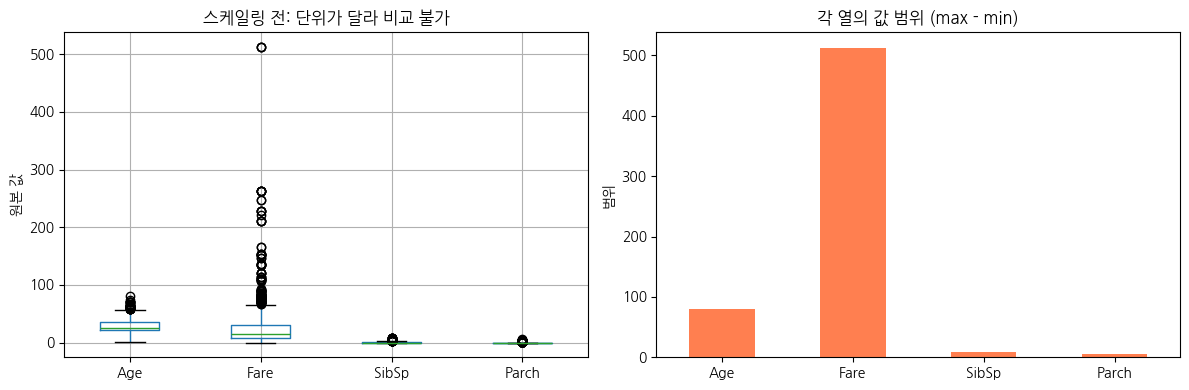

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 원본 데이터 박스플롯
df_4.boxplot(ax=axes[0])
axes[0].set_title('스케일링 전: 단위가 달라 비교 불가')
axes[0].set_ylabel('원본 값')


# 각 열의 범위를 수치로 확인
ranges = df_4.max() - df_4.min() # 열간 범위 차이가 크면 스케일링 필요
ranges.plot(kind='bar', ax = axes[1], color='coral')
axes[1].set_title('각 열의 값 범위 (max - min)')
axes[1].set_ylabel('범위')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [22]:
minmax_scaler = MinMaxScaler()
df_4_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_4),
    columns=df_4.columns
)

print("MinMaxScaler 결과: ")
print(df_4_minmax.describe().round(3))

#특정 값 역변환(스케일링 된 값 -> 원래 값 복원)
sample = df_4_minmax.iloc[:3] # 상위 3행 선택
original = minmax_scaler.inverse_transform(sample)
print("\n 역변환 결과 (원래 값):")
print(pd.DataFrame(original, columns=df_4.columns).round(2))

MinMaxScaler 결과: 
           Age     Fare    SibSp    Parch
count  891.000  891.000  891.000  891.000
mean     0.361    0.063    0.065    0.064
std      0.167    0.097    0.138    0.134
min      0.000    0.000    0.000    0.000
25%      0.265    0.015    0.000    0.000
50%      0.321    0.028    0.000    0.000
75%      0.447    0.061    0.125    0.000
max      1.000    1.000    1.000    1.000

 역변환 결과 (원래 값):
    Age   Fare  SibSp  Parch
0  22.0   7.25    1.0    0.0
1  38.0  71.28    1.0    0.0
2  26.0   7.92    0.0    0.0


### 실습 3. StandardScaler 적용

In [29]:
standard_scaler = StandardScaler()
df_4_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_4),
    columns=df_4.columns
)

print("standardScaler 결과: ")
print(df_4_standard.describe().round(3)) # 평균 mean 0, 표준편차std1로 모든 열이 동일한 척도를 가짐

print("\n 학습된 평균값:", standard_scaler.mean_.round(2)) # fit()에서 계산한 각 열의 평균
print("학습된 표준편차:", standard_scaler.scale_.round(2)) # fit()에서 계산한 각 열의 표준편차



standardScaler 결과: 
           Age     Fare    SibSp    Parch
count  891.000  891.000  891.000  891.000
mean     0.000    0.000    0.000    0.000
std      1.001    1.001    1.001    1.001
min     -2.158   -0.648   -0.475   -0.474
25%     -0.572   -0.489   -0.475   -0.474
50%     -0.234   -0.357   -0.475   -0.474
75%      0.518   -0.024    0.433   -0.474
max      3.827    9.667    6.784    6.974

 학습된 평균값: [29.11 32.2   0.52  0.38]
학습된 표준편차: [13.3  49.67  1.1   0.81]


In [24]:
#RobustScaler 적용
robust_scaler = RobustScaler()
df_4_robust = pd.DataFrame(
    robust_scaler.fit_transform(df_4),
    columns = df_4.columns
)
print('RobustScaler 결과:')
print(df_4_robust.describe().round(3)) #중앙값 = 0. IQR(사분위범위) = 1 기준으로 변환

# 학습된 중앙값 / IQR 확인 (fit 단계에서 저장된 값)
print('\n 학습된 중앙값:', robust_scaler.center_.round(2)) #fit()에서 계산한 각 열의 중앙값
print('학습된 IQR:', robust_scaler.scale_.round(2))      #fit()에서 계산한 각 열의 IQR(Q3 - Q1)

RobustScaler 결과:
           Age     Fare    SibSp    Parch
count  891.000  891.000  891.000  891.000
mean     0.215    0.769    0.523    0.382
std      0.918    2.152    1.103    0.806
min     -1.764   -0.626    0.000    0.000
25%     -0.310   -0.283    0.000    0.000
50%      0.000    0.000    0.000    0.000
75%      0.690    0.717    1.000    0.000
max      3.724   21.563    8.000    6.000

 학습된 중앙값: [26.   14.45  0.    0.  ]
학습된 IQR: [14.5  23.09  1.    1.  ]


### 실습 5. 세 스케일러 결과 비교 시각화

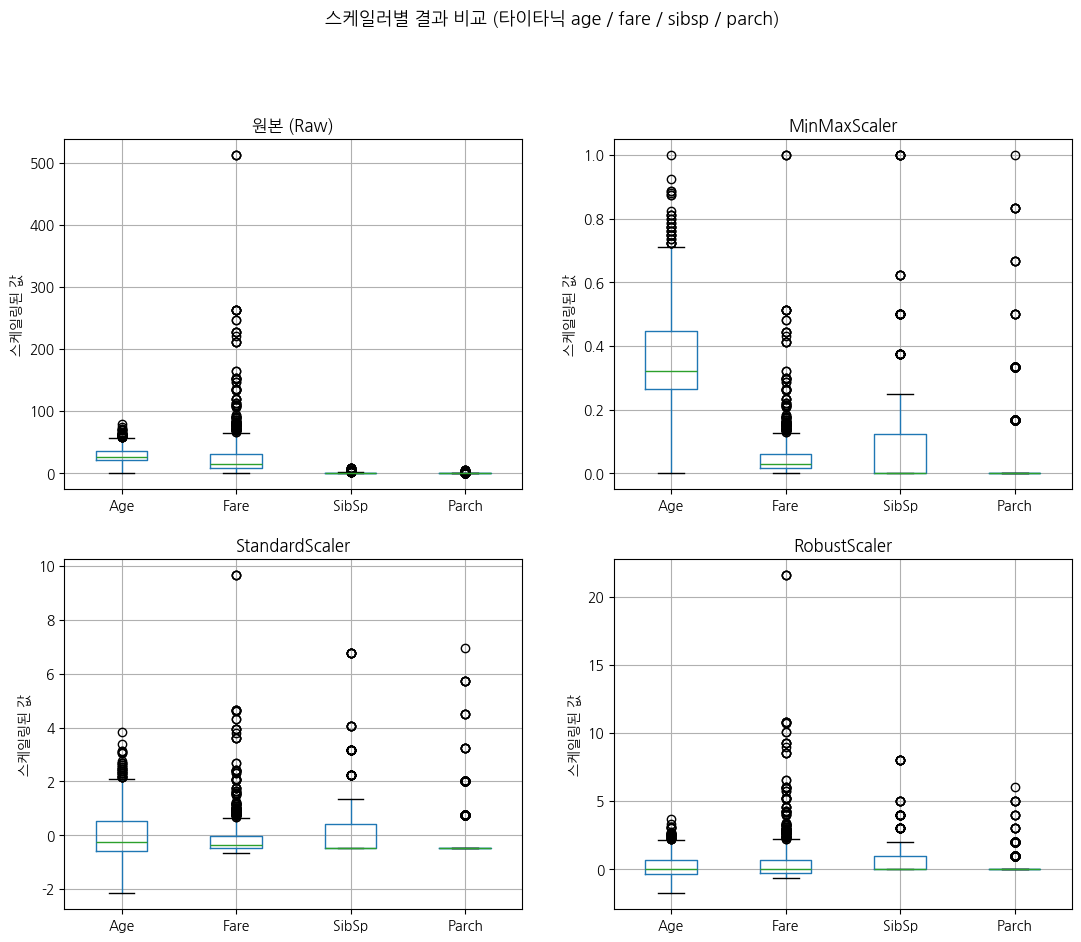

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10)) # 2행 2열 서브플롯 생성

datasets = {
    '원본 (Raw)': df_4,
    'MinMaxScaler': df_4_minmax,
    'StandardScaler': df_4_standard,
    'RobustScaler': df_4_robust
} # 딕셔너리로 제목과 데이터를 묶어 관리

for ax, (title, data) in zip(axes.flatten(), datasets.items()): #axes[0]
  data.boxplot(ax=ax)
  ax.set_title(title)
  ax.set_ylabel('스케일링된 값')
  ax.tick_params(axis='x', rotation=0)

  plt.suptitle('스케일러별 결과 비교 (타이타닉 age / fare / sibsp / parch)', fontsize=13, y=1.01)

### 실습 6. 이상치가 스케일링에 미치는 영향

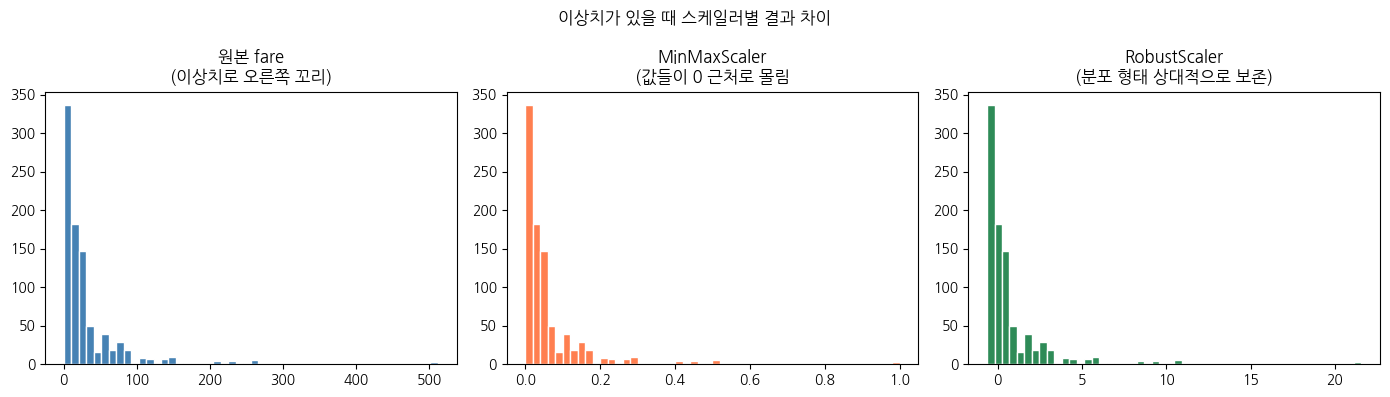

MinMax: 중앙 50% 범위 = 0.015) ~ 0.061
Robust: 중앙 50% 범위 = -0.283) ~ 0.717


In [39]:
# 이상치가 있는 Fare 열에서 MInMaxScaler vs RobustScaler 효과 비교
fare = df_4[['Fare']].copy()
# MinMaxScaler: 이상치(512달러)가 max 기준이 되어 일반값들이 0 근처로 몰림
mm = MinMaxScaler()
fare_mm = mm.fit_transform(fare)
#RobustScaler: 중앙값 IQR 기준이라 이상치가 기준값 계산에 포함되지 않아 일반값 분포 보존
rb = RobustScaler()
fare_rb = rb.fit_transform(fare)

# 그래프 그리기
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(fare['Fare'], bins = 50, color = 'steelblue', edgecolor="white")
axes[0].set_title('원본 fare\n(이상치로 오른쪽 꼬리)')

axes[1].hist(fare_mm, bins = 50, color = 'coral', edgecolor="white")
axes[1].set_title('MinMaxScaler\n(값들이 0 근처로 몰림')

axes[2].hist(fare_rb, bins = 50, color = 'seagreen', edgecolor="white")
axes[2].set_title('RobustScaler\n(분포 형태 상대적으로 보존)')

plt.suptitle('이상치가 있을 때 스케일러별 결과 차이', fontsize=12)
plt.tight_layout()
plt.show()

# 중앙 50% 값(Q1~Q3)의 범위로 분포의 퍼짐 정도 비교
print(f"MinMax: 중앙 50% 범위 = {np.percentile(fare_mm, 25):.3f}) ~ {np.percentile(fare_mm, 75):.3f}")
print(f"Robust: 중앙 50% 범위 = {np.percentile(fare_rb, 25):.3f}) ~ {np.percentile(fare_rb, 75):.3f}")


### 실습 7. 훈련/테스트 분리 후 올바른 스케일링

In [43]:
from sklearn.model_selection import train_test_split

# 데이터 분리
X = df_4[['Age', 'Fare']]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42) # 전체 데이터를 80%(훈련):20%(테스트)로 분리

print(f"훈련 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

# 핵심 규칙: fit은 훈련 데이터에만, trnasform은 훈련 테스트 모두에

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 학습된 통계 확인 (훈련 데이터 기준으로 fit된 값)
print(f"\n훈련 데이터 평균: age = {scaer.mean_[0]:.2f}, fare={scaler.mean_[1]:.2f}")

# 변환 결과 확인
train_df = pd.DataFrame(X_train_scaled, columns=['Age', 'Fare'])
test_df = pd.DataFrame(X_test_scaled, columns=['Age', 'Fare'])
print(f"\n훈련 스케일링 후 평균: {train_df.mean().round(4).values}")
print(f"테스트 스케일링 후 평균: {(test_df.mean).round(4).values}") # NumPy 배열 형태로 변환 [Age 평균 Fare 평균]
# 테스트 스케일링 후 평균은 0이 아닐 수 있음. 훈련 통계로 변환했으므로 정상적인 현상


훈련 데이터: (712, 2)
테스트 데이터: (179, 2)


### 실습 8. 종합-타이타닉 전처리 파이프라인에 스케일링 추가

In [47]:
from sklearn.pipeline import Pipeline
from sklearn. impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 이미 결측치가 처리된 titanic_clean 데이터 사용
titanic_pipe = titanic_clean[['Age', 'Fare', 'SibSp', 'Parch']].copy()
pipe = Pipeline({
    ('imputer', SimpleImputer(strategy='median')), # 결측치를 각 열의 중앙값으로 채워 넣기
    ('scaler', StandardScaler())

}) #Pipeline은 단계를 순서대로 자동 실행

# 파이프라인의 모든 단계를 순서대로 실행
result = pipe.fit_transform(titanic_pipe)
result_df = pd.DataFrame(result, columns = titanic_pipe.columns)

print("파이프라인 결과:")
print(result_df.describe().round(3))

# 파이프라인 구조 확인
for name, step in pipe.steps:
  print(f"{name}: {step}")